# Stage 1: Self-Attention (Scaled Dot-Product Attention)

## The Foundation of Transformers

Self-attention is the **core mechanism** that makes transformers so powerful. It allows each token to "attend" to every other token in the sequence.

### Key Intuition: Library Analogy
- **Query (Q)**: Your question - "What information do I need?"
- **Key (K)**: Labels/tags - "What information does each token have?"
- **Value (V)**: Content - "What is the actual information?"

### The Formula
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

**Why divide by √d_k?** 
- Dot products can get very large when d_k is big
- Large values push softmax into regions with tiny gradients
- Scaling keeps gradients healthy for training

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [3]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """
    Scaled Dot-Product Attention
    
    Args:
        query: (batch, seq_len, d_k) - what we're looking for
        key:   (batch, seq_len, d_k) - what each position has
        value: (batch, seq_len, d_v) - the actual content
        mask:  optional mask to hide certain positions
    
    Returns:
        output: weighted sum of values
        attention_weights: the attention scores (useful for visualization)
    """
    # Step 1: Get the dimension for scaling
    d_k = query.size(-1)
    
    # Step 2: Compute attention scores (Q @ K^T)
    # Shape: (batch, seq_len, seq_len)
    scores = torch.matmul(query, key.transpose(-2, -1))
    
    # Step 3: Scale by sqrt(d_k) to prevent vanishing gradients
    scores = scores / math.sqrt(d_k)
    
    # Step 4: Apply mask if provided (for causal attention)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    
    # Step 5: Softmax to get probabilities (each row sums to 1)
    attention_weights = F.softmax(scores, dim=-1)  # Note: dim=-1, not dim=1
    
    # Step 6: Multiply by values to get weighted output
    output = torch.matmul(attention_weights, value)
    
    return output, attention_weights

In [4]:
# Create sample data
batch_size = 1
seq_len = 4      # 4 tokens
d_model = 8      # embedding dimension

# Random embeddings for 4 tokens
torch.manual_seed(42)  # for reproducibility
x = torch.randn(batch_size, seq_len, d_model)

print("Input shape:", x.shape)
print("\nInput embeddings (each row is a token):")
print(x[0])

Input shape: torch.Size([1, 4, 8])

Input embeddings (each row is a token):
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,  0.7624],
        [ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806],
        [ 1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418, -0.2516,  0.8599]])


## Creating Query, Key, Value

In real transformers, Q, K, V are **learned projections** of the input:

```
Q = X @ W_Q   (What am I looking for?)
K = X @ W_K   (What do I have to offer?)
V = X @ W_V   (What is my actual content?)
```

For now, let's keep it simple and use the same input as Q, K, and V:

In [6]:
# For this simple example: Q = K = V = x
# (In practice, these are different learned projections)
query = x
key = x
value = x

# Run attention!
output, attention_weights = scaled_dot_product_attention(query, key, value)

print("Output shape:", output.shape)
print("\nAttention weights (who attends to whom):")
print(attention_weights[0])

Output shape: torch.Size([1, 4, 8])

Attention weights (who attends to whom):
tensor([[0.9846, 0.0095, 0.0013, 0.0046],
        [0.1401, 0.7680, 0.0351, 0.0568],
        [0.0144, 0.0264, 0.8073, 0.1519],
        [0.0799, 0.0670, 0.2379, 0.6153]])


## Understanding the Attention Matrix

The attention weights matrix shows **how much each token attends to every other token**:

```
          Token 0   Token 1   Token 2   Token 3
Token 0 [  0.25      0.25      0.25      0.25  ]  → Row sums to 1.0
Token 1 [  0.20      0.30      0.30      0.20  ]  → Row sums to 1.0
...
```

**Reading the matrix:**
- Row i, Column j = How much token i attends to token j
- Each row sums to 1.0 (softmax!)
- High values = strong attention

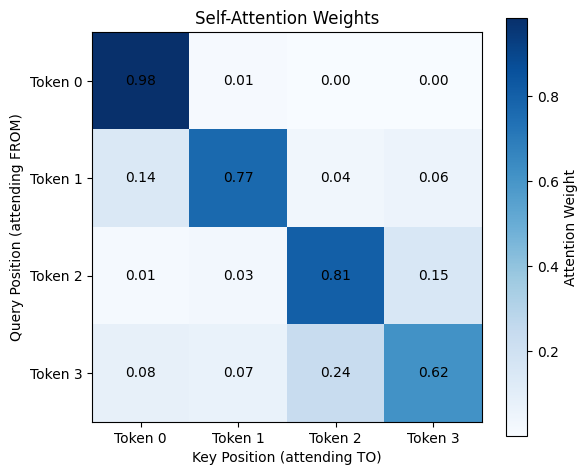

In [57]:
import matplotlib.pyplot as plt

# Visualize attention weights as a heatmap
plt.figure(figsize=(6, 5))
plt.imshow(attention_weights[0].detach().numpy(), cmap='Blues')
plt.colorbar(label='Attention Weight')
plt.xlabel('Key Position (attending TO)')
plt.ylabel('Query Position (attending FROM)')
plt.title('Self-Attention Weights')
plt.xticks(range(seq_len), [f'Token {i}' for i in range(seq_len)])
plt.yticks(range(seq_len), [f'Token {i}' for i in range(seq_len)])

# Add values on the heatmap
for i in range(seq_len):
    for j in range(seq_len):
        plt.text(j, i, f'{attention_weights[0][i, j]:.2f}', 
                ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## Causal Masking (For GPT-style models)

In **autoregressive models** (like GPT), each token should only attend to **previous tokens** - not future ones!

Why? Because during generation, future tokens don't exist yet.

```
Causal Mask:
          Tok0  Tok1  Tok2  Tok3
Tok0    [  1     0     0     0  ]  ← Can only see itself
Tok1    [  1     1     0     0  ]  ← Can see Tok0, Tok1
Tok2    [  1     1     1     0  ]  ← Can see Tok0, Tok1, Tok2
Tok3    [  1     1     1     1  ]  ← Can see all previous
```

In [7]:
# Create a causal mask (lower triangular matrix)
causal_mask = torch.tril(torch.ones(seq_len, seq_len))
print("Causal Mask (1 = can attend, 0 = blocked):")
print(causal_mask)

# Apply causal attention
output_causal, attention_causal = scaled_dot_product_attention(
    query, key, value, mask=causal_mask
)

print("\nCausal Attention Weights:")
print(attention_causal[0])

Causal Mask (1 = can attend, 0 = blocked):
tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])

Causal Attention Weights:
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.1543, 0.8457, 0.0000, 0.0000],
        [0.0170, 0.0311, 0.9519, 0.0000],
        [0.0799, 0.0670, 0.2379, 0.6153]])


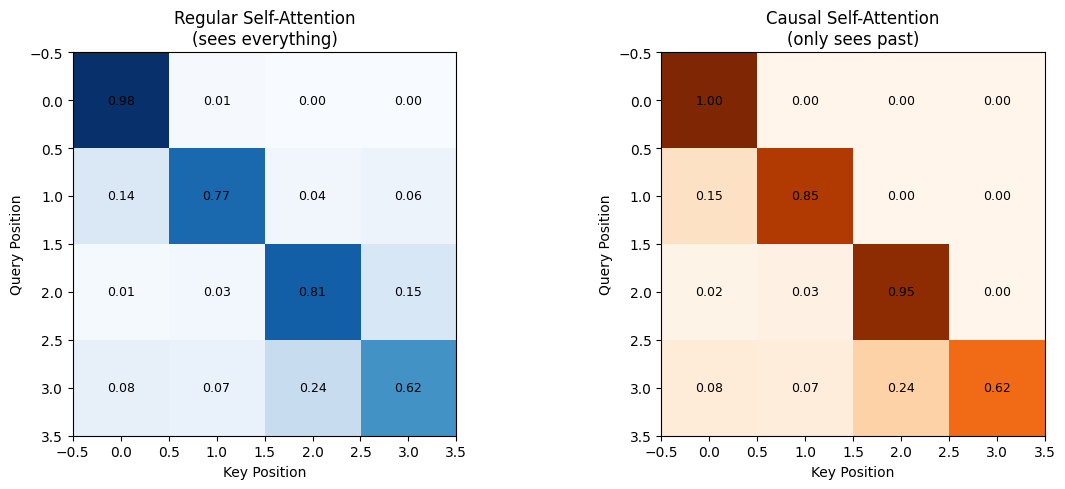

In [59]:
# Compare: Regular vs Causal Attention
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Regular attention
ax1 = axes[0]
im1 = ax1.imshow(attention_weights[0].detach().numpy(), cmap='Blues')
ax1.set_title('Regular Self-Attention\n(sees everything)')
ax1.set_xlabel('Key Position')
ax1.set_ylabel('Query Position')
for i in range(seq_len):
    for j in range(seq_len):
        ax1.text(j, i, f'{attention_weights[0][i, j]:.2f}', 
                ha='center', va='center', fontsize=9)

# Causal attention
ax2 = axes[1]
im2 = ax2.imshow(attention_causal[0].detach().numpy(), cmap='Oranges')
ax2.set_title('Causal Self-Attention\n(only sees past)')
ax2.set_xlabel('Key Position')
ax2.set_ylabel('Query Position')
for i in range(seq_len):
    for j in range(seq_len):
        ax2.text(j, i, f'{attention_causal[0][i, j]:.2f}', 
                ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
# Complete Self-Attention Module (with Learned Projections)

Now let's build a **proper self-attention layer** as used in real transformers:

```
Input X (batch, seq_len, d_model)
    │
    ├───► W_Q ───► Q (batch, seq_len, d_k)
    │
    ├───► W_K ───► K (batch, seq_len, d_k)
    │
    └───► W_V ───► V (batch, seq_len, d_v)
                    │
                    ▼
        Scaled Dot-Product Attention
                    │
                    ▼
               W_O ───► Output (batch, seq_len, d_model)
```

In [10]:
class SelfAttention(nn.Module):
    """
    Self-Attention Layer with Learned Projections
    
    This is the building block that processes a single attention head.
    """
    
    def __init__(self, d_model, d_k=None, d_v=None):
        """
        Args:
            d_model: Input/output dimension
            d_k: Key/Query dimension (default: d_model)
            d_v: Value dimension (default: d_model)
        """
        super().__init__()
        
        d_k = d_k or d_model
        d_v = d_v or d_model
        
        # Learned projection matrices
        self.W_Q = nn.Linear(d_model, d_k, bias=False)  # Query projection
        self.W_K = nn.Linear(d_model, d_k, bias=False)  # Key projection
        self.W_V = nn.Linear(d_model, d_v, bias=False)  # Value projection
        self.W_O = nn.Linear(d_v, d_model, bias=False)  # Output projection
        
        self.d_k = d_k
        
    def forward(self, x, mask=None):
        """
        Args:
            x: Input tensor (batch, seq_len, d_model)
            mask: Optional attention mask
        
        Returns:
            output: (batch, seq_len, d_model)
            attention_weights: (batch, seq_len, seq_len)
        """
        # Step 1: Project input to Q, K, V
        Q = self.W_Q(x)  # (batch, seq_len, d_k)
        K = self.W_K(x)  # (batch, seq_len, d_k)
        V = self.W_V(x)  # (batch, seq_len, d_v)
        
        # Step 2: Compute scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attention_weights = F.softmax(scores, dim=-1)
        
        # Step 3: Apply attention to values
        context = torch.matmul(attention_weights, V)
        
        # Step 4: Project back to d_model
        output = self.W_O(context)
        
        return output, attention_weights

In [12]:
# Test our SelfAttention module
d_model = 64 # Model dimension
self_attn = SelfAttention(d_model=d_model)

# Create input: batch of 2 sequences, each with 10 tokens
x = torch.randn(2, 10, d_model)

# Forward pass
output, attn_weights = self_attn(x)
print(f"Input shape:  {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"\nNumber of learnable parameters: {sum(p.numel() for p in self_attn.parameters()):,}")

Input shape:  torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])
Attention weights shape: torch.Size([2, 10, 10])

Number of learnable parameters: 16,384


4. **Research**: How would you modify this for cross-attention (attending to a different sequence)?

In [62]:
class CrossAttention(nn.Module):
    """
    Cross-Attention Layer
    
    Query comes from target sequence X
    Key and Value come from source sequence Y
    """
    
    def __init__(self, d_model, d_k=None, d_v=None, dropout=0.1):
        """
        Args:
            d_model: Input/output dimension (assumes same for both sequences)
            d_k: Key/Query dimension (default: d_model)
            d_v: Value dimension (default: d_model)
            dropout: Dropout probability
        """
        super().__init__()
        
        d_k = d_k or d_model
        d_v = d_v or d_model
        
        # Query projection (for target sequence)
        self.W_Q = nn.Linear(d_model, d_k, bias=False)
        
        # Key and Value projections (for source sequence)
        self.W_K = nn.Linear(d_model, d_k, bias=False)
        self.W_V = nn.Linear(d_model, d_v, bias=False)
        
        # Output projection
        self.W_O = nn.Linear(d_v, d_model, bias=False)
        
        self.attn_dropout = nn.Dropout(dropout)
        self.d_k = d_k
        
    def forward(self, x, context, mask=None):
        """
        Args:
            x: Target sequence (batch, target_len, d_model) - generates Q
            context: Source sequence (batch, source_len, d_model) - generates K, V
            mask: Optional mask (batch, target_len, source_len)
        
        Returns:
            output: (batch, target_len, d_model)
            attention_weights: (batch, target_len, source_len)
        """
        # Query from target sequence
        Q = self.W_Q(x)          # (batch, target_len, d_k)
        
        # Key and Value from source/context sequence
        K = self.W_K(context)    # (batch, source_len, d_k)
        V = self.W_V(context)    # (batch, source_len, d_v)
        
        # Compute attention scores
        # Q: (batch, target_len, d_k)
        # K^T: (batch, d_k, source_len)
        # scores: (batch, target_len, source_len)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.attn_dropout(attention_weights)
        
        # Apply attention to values
        # attn: (batch, target_len, source_len)
        # V: (batch, source_len, d_v)
        # output: (batch, target_len, d_v)
        output = torch.matmul(attention_weights, V)
        
        # Project back
        output = self.W_O(output)
        
        return output, attention_weights

In [63]:
# Example: Translation - French attends to English
d_model = 64

cross_attn = CrossAttention(d_model=d_model)

# English source: "The cat sat" (3 tokens)
english = torch.randn(1, 3, d_model)  # (batch, source_len, d_model)

# French target: "Le chat assis" (3 tokens) 
french = torch.randn(1, 3, d_model)   # (batch, target_len, d_model)

# Cross attention: French queries, English keys/values
output, attn_weights = cross_attn(x=french, context=english)

print(f"French (target) shape:  {french.shape}")
print(f"English (source) shape: {english.shape}")
print(f"Output shape:           {output.shape}")
print(f"Attention shape:        {attn_weights.shape}")
print(f"\nAttention matrix (French → English):")
print(attn_weights[0])

French (target) shape:  torch.Size([1, 3, 64])
English (source) shape: torch.Size([1, 3, 64])
Output shape:           torch.Size([1, 3, 64])
Attention shape:        torch.Size([1, 3, 3])

Attention matrix (French → English):
tensor([[0.3009, 0.0000, 0.5318],
        [0.2835, 0.0000, 0.4804],
        [0.2313, 0.4520, 0.4278]], grad_fn=<SelectBackward0>)


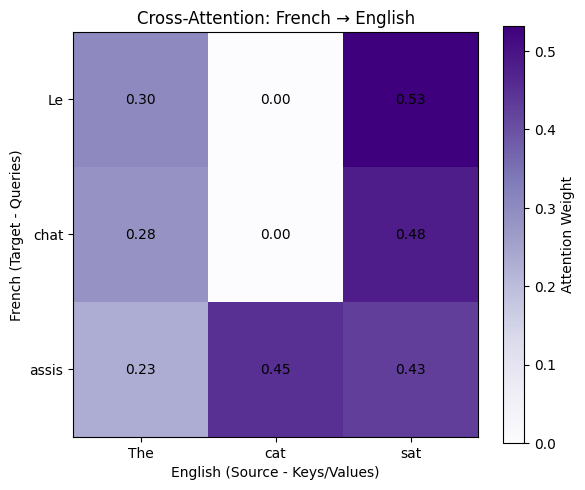

In [64]:
# Visualize cross-attention between sequences
english_tokens = ["The", "cat", "sat"]
french_tokens = ["Le", "chat", "assis"]

plt.figure(figsize=(6, 5))
plt.imshow(attn_weights[0].detach().numpy(), cmap='Purples')
plt.colorbar(label='Attention Weight')
plt.xlabel('English (Source - Keys/Values)')
plt.ylabel('French (Target - Queries)')
plt.title('Cross-Attention: French → English')
plt.xticks(range(3), english_tokens)
plt.yticks(range(3), french_tokens)

for i in range(3):
    for j in range(3):
        plt.text(j, i, f'{attn_weights[0][i, j]:.2f}', 
                ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()